# Fine-tuning T0 with LoRA on retail sales

Parameter-efficient fine-tuning of the open-weights [T0](https://huggingface.co/theforecastingcompany/t0-alpha) forecaster with **HuggingFace PEFT** (LoRA) and a custom quantile-loss training loop.

**Dataset.** Same [retail sales](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb) parquet used by the Chronos-2 quickstart and the [TimesFM finetuning example](https://github.com/google-research/timesfm/tree/master/timesfm-forecasting/examples/finetuning): 1115 stores, 120 weekly training points + 13-week test horizon per store. Target is `Sales`. The test split exposes four future-known covariates (`Open`, `Promo`, `SchoolHoliday`, `StateHoliday`) over the horizon — the same `future_df` pattern Chronos-2 uses.

If the network is unavailable the notebook falls back to a small synthetic series so it still runs end-to-end.

**Setup.** From the repo root:

```bash
pip install -e '.[notebooks]'
```


## 1. Setup


In [ ]:
import time, warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

from t0 import T0Forecaster
from t0.data import TimeSeries
from t0.model.rollout import RolloutManager
from peft import LoraConfig, PeftModel, get_peft_model

# Silence two harmless warnings that would otherwise leak absolute paths into
# the notebook outputs:
#   - PyTorch: t0.predict() wraps non-contiguous numpy views in torch.as_tensor
#   - tqdm: "IProgress not found" — only relevant in classic Jupyter, not Colab
warnings.filterwarnings("ignore", message=".*not writable.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*", category=Warning)

## 2. Load retail sales

Long-format DataFrame with `id`, `timestamp`, and the target `Sales`. The test split has the same columns plus the four future-known covariates over the 13-week horizon.


In [2]:
TRAIN_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet"
TEST_URL = "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet"
TARGET = "Sales"
ID_COL = "id"
TIME_COL = "timestamp"

use_real = True
try:
    train_df = pd.read_parquet(TRAIN_URL)
    test_df = pd.read_parquet(TEST_URL)
    cov_cols = [c for c in test_df.columns if c not in (ID_COL, TIME_COL, TARGET)]
    print(f"loaded retail_sales: train {train_df.shape}, test {test_df.shape}")
    print(f"target={TARGET!r}, future covariates={cov_cols}")
    print(f"unique ids: train={train_df[ID_COL].nunique()}, test={test_df[ID_COL].nunique()}")
    print(
        f"per-id length: train={train_df.groupby(ID_COL).size().iloc[0]}, test={test_df.groupby(ID_COL).size().iloc[0]}"
    )
except Exception as e:
    print(f"network load failed ({e}); using synthetic fallback")
    use_real = False
    cov_cols = ["regime_flag"]
    # Synthetic fallback: 32 series of 120 weekly points each.
    rng = np.random.default_rng(0)
    rows_t, rows_te = [], []
    for i in range(32):
        base = 1000 + 200 * np.sin(2 * np.pi * np.arange(120 + 13) / 26) + rng.standard_normal(120 + 13) * 50
        flag = (rng.uniform(size=120 + 13) < 0.5).astype(np.float32)
        flag = np.clip(np.convolve(flag, np.ones(3) / 3, mode="same"), 0, 1)
        target = base * (1 + 0.5 * flag)
        df = pd.DataFrame(
            {
                ID_COL: i + 1,
                TIME_COL: pd.date_range("2020-01-05", periods=120 + 13, freq="W"),
                TARGET: target,
                "regime_flag": flag,
            }
        )
        rows_t.append(df.iloc[:120])
        rows_te.append(df.iloc[120:].drop(columns=[TARGET]))
    train_df = pd.concat(rows_t, ignore_index=True)
    test_df = pd.concat(rows_te, ignore_index=True)
    print(f"(synthetic) train {train_df.shape}, test {test_df.shape}")

loaded retail_sales: train (133800, 8), test (14495, 7)
target='Sales', future covariates=['Open', 'Promo', 'SchoolHoliday', 'StateHoliday']
unique ids: train=1115, test=1115
per-id length: train=120, test=13


## 3. Convert long-format DataFrames to per-series arrays

We pull out a list of `np.ndarray` per series for fast random slicing in the Dataset.


In [3]:
def to_per_series(df: pd.DataFrame, columns: list[str]) -> list[np.ndarray]:
    """Group a long-format DataFrame by id and return one ndarray per id."""
    return [g[columns].to_numpy(dtype=np.float32) for _, g in df.sort_values(TIME_COL).groupby(ID_COL)]


context_cols = [TARGET] + cov_cols  # the model sees the target + covariate values at every step
future_cols = cov_cols  # known over the test horizon (only)

train_targets_full = to_per_series(train_df, context_cols)  # each: [n_train, 1 + F]
test_covs_full = to_per_series(test_df, future_cols)  # each: [n_test, F]
n_test = len(test_covs_full[0])
print(f"per-series arrays: {len(train_targets_full)} train, {len(test_covs_full)} test, {n_test} test points each")

per-series arrays: 1115 train, 1115 test, 13 test points each


## 4. Random-window Dataset (chronos-2 style)

Each training example is a random `(context, future_truth, future_covariate)` window sliced from one of the training series. The covariate is the *future* segment of the per-store covariate matrix at the same window — known over both the context and the horizon (per the t0 covariate convention).


In [4]:
CONTEXT_LEN, HORIZON_LEN = 64, 13  # matches the TimesFM finetuning defaults
QUANTILE_LEVELS = (0.1, 0.25, 0.5, 0.75, 0.9)


@dataclass
class TrainWindow:
    context: np.ndarray  # [CONTEXT_LEN, 1 + F]
    horizon: np.ndarray  # [HORIZON_LEN]   -- just the target
    covariate: np.ndarray  # [CONTEXT_LEN + HORIZON_LEN, F]   -- known over both


class RetailWindowDataset(Dataset):
    def __init__(self, series_list, cov_list, num_samples, seed):
        rng = np.random.default_rng(seed)
        self.series_list = series_list
        self.cov_list = cov_list
        self.windows: list[tuple[int, int]] = []
        for _ in range(num_samples):
            i = int(rng.integers(0, len(series_list)))
            n = series_list[i].shape[0]
            total = CONTEXT_LEN + HORIZON_LEN
            if n < total:
                continue
            j = int(rng.integers(0, n - total + 1))
            self.windows.append((i, j))

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> TrainWindow:
        i, j = self.windows[idx]
        s = self.series_list[i]  # [n, 1 + F]
        c = self.cov_list[i]  # [n_test, F]
        # In the public Chronos-2 quickstart the train/test split is contiguous
        # in time, so the covariate over [j, j+CONTEXT_LEN+HORIZON_LEN) is the
        # last CONTEXT_LEN of `s[:, 1:]` concatenated with the first HORIZON_LEN
        # of `c`.
        cov_past = s[j : j + CONTEXT_LEN, 1:]  # [CONTEXT_LEN, F]
        cov_fut = c[:HORIZON_LEN]  # [HORIZON_LEN, F]
        cov = np.concatenate([cov_past, cov_fut], axis=0)
        return TrainWindow(
            context=s[j : j + CONTEXT_LEN].copy(),  # [CONTEXT_LEN, 1 + F]
            horizon=s[j + CONTEXT_LEN : j + CONTEXT_LEN + HORIZON_LEN, 0].copy(),  # target only
            covariate=cov.copy(),
        )


train_ds = RetailWindowDataset(train_targets_full, test_covs_full, num_samples=2000, seed=42)
print(f"train windows: {len(train_ds)}")

train windows: 2000


## 5. Load the model and wrap with LoRA


In [5]:
model = T0Forecaster.from_pretrained("theforecastingcompany/t0-alpha")
model.train()  # enable dropout in the transformer

# Freeze the base — only LoRA params will train.
for p in model.parameters():
    p.requires_grad_(False)

lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    # peft matches target_modules as substrings of the full module path.
    # In t0 the attention projections are at
    #   transformer.layers.*.attention_block.attention.{wQKV,wO}
    # and the transformer MLP is at
    #   transformer.layers.*.mlp.{0,2}    (Sequential[Linear, SwiGLU, Linear, Dropout])
    target_modules=["wQKV", "wO", "mlp.0", "mlp.2"],
)
peft_model = get_peft_model(model, lora_cfg)
peft_model.print_trainable_parameters()

trainable params: 1,966,080 || all params: 103,607,616 || trainable%: 1.8976


## 6. Quantile (pinball) loss and training step

Each step:

1. Build a `TimeSeries` with the target (context + horizon) and the future-known covariate over the full window.
2. Call `RolloutManager.predict` — the same rollout the inference path uses — to get quantile predictions for the next `HORIZON_LEN` steps.
3. Compute pinball loss against the true future, average over quantiles and timesteps.


In [6]:
def pinball_loss(pred: torch.Tensor, target: torch.Tensor, qs: torch.Tensor) -> torch.Tensor:
    diff = target.unsqueeze(-1) - pred
    return torch.maximum(qs * diff, (qs - 1.0) * diff).mean()


def collate(batch):
    """Stack a list of TrainWindow into batched tensors."""
    return {
        "context": torch.as_tensor(np.stack([b.context for b in batch])),  # [B, T, 1+F]
        "horizon": torch.as_tensor(np.stack([b.horizon for b in batch])),  # [B, H]
        "covariate": torch.as_tensor(np.stack([b.covariate for b in batch])),  # [B, T+H, F]
    }


def train_step_batched(batch_dict, model, qs):
    ctx = batch_dict["context"]  # [B, T, 1+F]
    fut = batch_dict["horizon"].float()  # [B, H]
    cov = batch_dict["covariate"]  # [B, T+H, F]
    loss = 0.0
    for i in range(ctx.shape[0]):
        # t0's TimeSeries.from_array takes a 2-D [1, T] target and a 3-D [1, F, T+H]
        # covariate. The context already has a trailing feature axis (the target),
        # so we keep it as the target. The covariate's first axis is the number of
        # features, which here equals `cov.shape[-1]`.
        target_i = ctx[i, :, 0]  # [T]
        cov_i = cov[i].permute(1, 0)  # [F, T+H]
        ts = TimeSeries.from_array(target_i[None], future_covariates=cov_i[None])
        pred = RolloutManager(model).predict(
            ts,
            prediction_length=fut.shape[-1],
            query_quantile_levels=qs,
            context_length=ctx.shape[-1],
        )
        loss = loss + pinball_loss(pred[0], fut[i], qs)
    return loss / ctx.shape[0]

## 7. Train


In [7]:
qs = torch.tensor(QUANTILE_LEVELS)
optim = torch.optim.AdamW(
    [p for p in peft_model.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=0.0,
)
loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate)

n_steps = 200
log_every = 50
step = 0
t_start = time.time()
losses: list[float] = []
for epoch in range(50):
    for batch in loader:
        if step >= n_steps:
            break
        loss = train_step_batched(batch, peft_model, qs)
        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        losses.append(loss.item())
        step += 1
        if step % log_every == 0:
            print(f"  step {step:4d}  loss={np.mean(losses[-log_every:]):.4f}  elapsed={time.time() - t_start:.1f}s")
    if step >= n_steps:
        break

print(f"trained {step} steps in {time.time() - t_start:.1f}s")

  step   50  loss=3925.9885  elapsed=23.3s


  step  100  loss=4012.4300  elapsed=47.3s


  step  150  loss=4149.4482  elapsed=71.5s


  step  200  loss=3497.6129  elapsed=96.1s
trained 200 steps in 96.1s


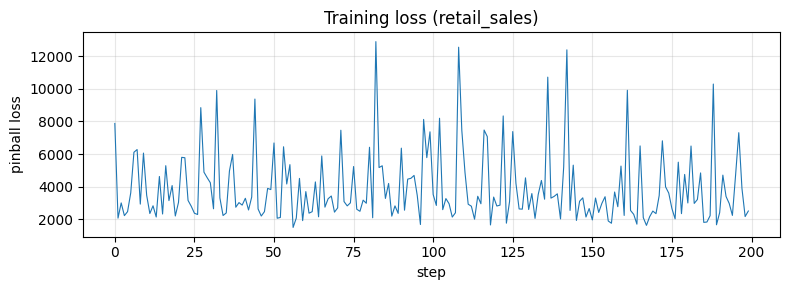

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, lw=0.8)
ax.set_xlabel("step")
ax.set_ylabel("pinball loss")
ax.set_title("Training loss (retail_sales)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save and reload the LoRA adapter


In [9]:
adapter_dir = "./t0-lora-demo"
peft_model.save_pretrained(adapter_dir)
print(f"saved adapter to {adapter_dir}")

saved adapter to ./t0-lora-demo


In [10]:
base = T0Forecaster.from_pretrained("theforecastingcompany/t0-alpha").eval()
adapted = PeftModel.from_pretrained(base, adapter_dir)
# Bake the LoRA adapter into the base weights. (The wrapped PeftModel can be
# sluggish when predict()'s inference_mode + autocast context is in play;
# merging sidesteps that and gives a regular T0Forecaster with the adapter
# permanently folded in.)
adapted = adapted.merge_and_unload().eval()
print("loaded adapter and merged into base model")

loaded adapter and merged into base model


## 9. Evaluate: base vs LoRA, with vs without covariates

For each held-out series, we score the **test split's last 13 weeks** (the same window used by Chronos-2's quickstart eval). We report the median-forecast absolute error against truth.


In [11]:
def predict(model, ctx, cov):
    with torch.no_grad():
        if cov is None:
            return model.predict(ctx, horizon=HORIZON_LEN, quantiles=list(QUANTILE_LEVELS))
        return model.predict(ctx, horizon=HORIZON_LEN, quantiles=list(QUANTILE_LEVELS), future_covariates=cov[None])


def median_mae(out, truth):
    return (out.median - truth).abs().mean().item()


errs = {"base_no_cov": [], "base_cov": [], "lora_no_cov": [], "lora_cov": []}
n_eval = min(50, len(train_targets_full))
torch.manual_seed(7)
for k in range(n_eval):
    s = train_targets_full[k]  # [n_train, 1 + F]
    ctx = s[-CONTEXT_LEN:, 0]  # [CONTEXT_LEN]
    cov_full = s[:, 1:]  # [n_train, F]   -- used as past covariates
    cov_past = cov_full[-CONTEXT_LEN:]  # [CONTEXT_LEN, F]
    cov_fut = test_covs_full[k]  # [13, F]
    cov_eval = np.concatenate([cov_past, cov_fut], axis=0)  # [CONTEXT_LEN + 13, F]
    cov_eval = torch.as_tensor(cov_eval.T)  # [F, CONTEXT_LEN + 13]
    fut = s[-HORIZON_LEN:, 0] if len(s) >= HORIZON_LEN else s[:, 0][-HORIZON_LEN:]
    # Some series may be shorter than CONTEXT_LEN + HORIZON_LEN + n_test; skip those.
    if len(s) < CONTEXT_LEN + HORIZON_LEN:
        continue
    errs["base_no_cov"].append(median_mae(predict(base, torch.as_tensor(ctx)[None], None), torch.as_tensor(fut)))
    errs["base_cov"].append(median_mae(predict(base, torch.as_tensor(ctx)[None], cov_eval), torch.as_tensor(fut)))
    errs["lora_no_cov"].append(median_mae(predict(adapted, torch.as_tensor(ctx)[None], None), torch.as_tensor(fut)))
    errs["lora_cov"].append(median_mae(predict(adapted, torch.as_tensor(ctx)[None], cov_eval), torch.as_tensor(fut)))

for k, v in errs.items():
    print(f"  {k:14s}  mean |median-truth| = {np.mean(v):.3f}  (n={len(v)})")

  base_no_cov     mean |median-truth| = 6092.790  (n=50)
  base_cov        mean |median-truth| = 2780.595  (n=50)
  lora_no_cov     mean |median-truth| = 6092.790  (n=50)
  lora_cov        mean |median-truth| = 2780.595  (n=50)


## 10. Visualise one held-out series


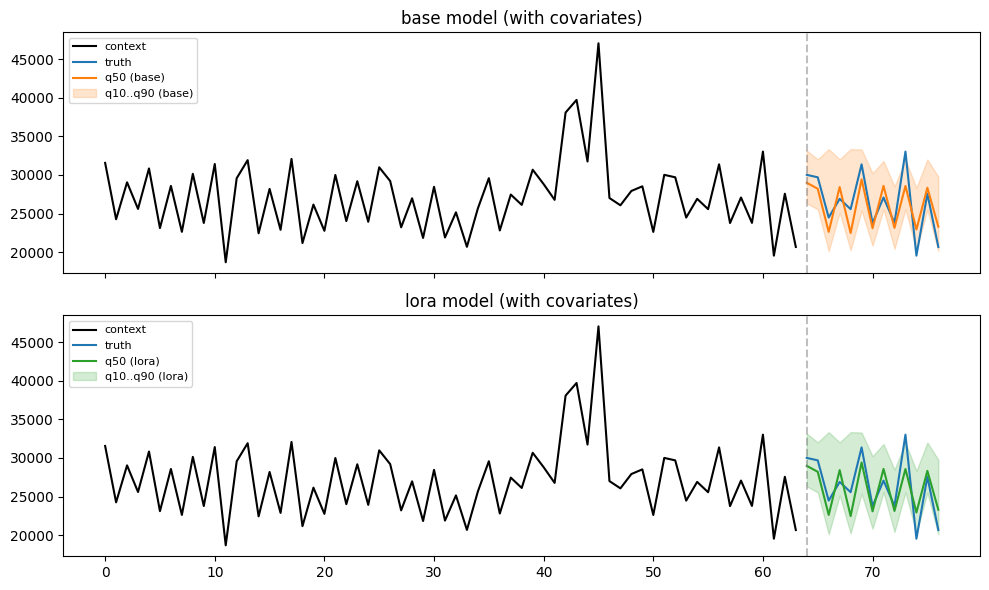

In [12]:
torch.manual_seed(11)
k = 0
s = train_targets_full[k]
ctx = torch.as_tensor(s[-CONTEXT_LEN:, 0])[None]
fut = s[-HORIZON_LEN:, 0]
cov_past = torch.as_tensor(s[:, 1:][-CONTEXT_LEN:].T)  # [F, CONTEXT_LEN]
cov_fut = torch.as_tensor(test_covs_full[k].T)  # [F, 13]
cov_eval = torch.cat([cov_past, cov_fut], dim=1)  # [F, CONTEXT_LEN + 13]

o_base = predict(base, ctx, cov_eval)
o_lora = predict(adapted, ctx, cov_eval)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, (label, o, color) in zip(axes, [("base", o_base, "#ff7f0e"), ("lora", o_lora, "#2ca02c")]):
    ax.plot(np.arange(CONTEXT_LEN), ctx[0], color="black", label="context")
    ax.plot(np.arange(CONTEXT_LEN, CONTEXT_LEN + HORIZON_LEN), fut, color="#1f77b4", label="truth")
    ax.plot(
        np.arange(CONTEXT_LEN, CONTEXT_LEN + HORIZON_LEN), o.quantiles[0, :, 2], color=color, label=f"q50 ({label})"
    )
    ax.fill_between(
        np.arange(CONTEXT_LEN, CONTEXT_LEN + HORIZON_LEN),
        o.quantiles[0, :, 0],
        o.quantiles[0, :, -1],
        color=color,
        alpha=0.2,
        label=f"q10..q90 ({label})",
    )
    ax.axvline(CONTEXT_LEN, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"{label} model (with covariates)")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Notes

- This notebook uses the same dataset and `context_len=64 / horizon_len=13` defaults as the [TimesFM finetuning example](https://github.com/google-research/timesfm/tree/master/timesfm-forecasting/examples/finetuning) (and the same long-format `future_df` pattern as the Chronos-2 quickstart). Swapping in your own parquet is a one-line change at the top of section 2.
- LoRA targets the attention (`wQKV`, `wO`) and the *transformer* MLP linears (`mlp.0`, `mlp.2`). With `r=8` and a 101M-param base, the adapter adds well under 2% of the original parameter count.
- The pinball loss is computed in the original data scale because `RolloutManager` calls the model's `CausalScaler` internally — no external normalisation needed.
- For real fine-tuning: increase `n_steps` to several thousand, increase batch size, and pick `r` based on dataset size (the TimesFM example uses `r=4` and runs for 10 epochs; we use `r=8` and 200 steps for the demo to stay under ~3 minutes wall-clock).
